# Appendix figure — seed-to-seed variance of SCARSE greedy accumulation

Produces a single figure for the appendix (suggested **Fig. G5, Appendix G**) showing why the
peptide datasets vary more across random seeds than the substitution datasets under SCARSE
(ESM-2 + GPR) with greedy top-k selection. Panels: (a) end-point std per dataset, (b) per-seed
trajectory fans, (c) the seed-to-seed spread growing over the rounds, (d) end-point performance
(x random) against the label spread of the initial seed, and (e) the same against the best label
present in the initial seed (full width).

> **Placement:** `code/workflow_simulation/seed_variance_analysis.ipynb` (next to `simulation.ipynb`).
>
> **Before running, check two things:** the `DATA_FILES` mapping (dataset name -> processed CSV),
> and that `reconstruct_initial_seed()` matches how `initialize_training_set()` draws the initial
> 20 peptides (`df.sample(n=20, random_state=seed)`).


In [1]:
import os, sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')
mpl.rcParams.update({'font.size':9,'axes.spines.top':False,'axes.spines.right':False})

# ---- paths (edit if needed) ----
RESULTS_DIR = 'simulation_results'          # holds df_all.csv (and/or runs/)
DATA_ROOT   = os.path.join('..', '..', 'data')
FIG_DIR     = 'simulation_results/figures/seed_variance'
os.makedirs(FIG_DIR, exist_ok=True)

SEQ_COL, SCORE_COL = 'sequence', 'score'
INITIAL_TRAIN_SIZE = 20
METRIC   = 'Top 10% peptides selected (%)'
SCARSE_REP, ACQUISITION = 'esm', 'greedy'

AMP_DATASETS = ['Ecoli_AMPs', 'Saureus_AMPs', 'Paeruginosa_AMPs']
HEMOPI2      = ['HemoPI2']
SUBSTITUTION_DATASETS = ['A0A247D711_LISMN','DN7A_SACS2','ENVZ_ECOLI','FKBP3_HUMAN',
                         'MAFG_MOUSE_sub','POLG_PESV_sub','SBI_STAAM','SDA_BACSU',
                         'SOX30_HUMAN','YNZC_BACSU_sub']

# dataset name (as in df_all.csv) -> processed CSV (used for the random baseline and the seed analysis)
DATA_FILES = {
    'Ecoli_AMPs':       os.path.join(DATA_ROOT, 'ecoli_amps',       'processed', 'EC_all_40.csv'),
    'Saureus_AMPs':     os.path.join(DATA_ROOT, 'saureus_amps',     'processed', 'SA_all_40.csv'),
    'Paeruginosa_AMPs': os.path.join(DATA_ROOT, 'paeruginosa_amps', 'processed', 'PA_all_40.csv'),
    'HemoPI2':          os.path.join(DATA_ROOT, 'hemopi2',          'processed', 'hemopi2_all.csv'),
}

# Optimisation direction per dataset. Almost every endpoint is "higher is better".
# HemoPI2 is the exception: its score is -log(HC50), where a LOWER value is less
# haemolytic and thus more desirable, so it is a minimize objective (matching the
# workflow's --direction minimize). We use this below to orient the raw seed scores
# so that "higher = more desirable" holds for every dataset, and +1 std on the
# panel (d)/(e) x-axes always means a better-than-average initial seed.
DATASET_DIRECTION = {d: 'maximize' for d in AMP_DATASETS + SUBSTITUTION_DATASETS}
DATASET_DIRECTION.update({d: 'minimize' for d in HEMOPI2})
def direction_sign(d):
    # +1 keeps the raw score, -1 flips a minimize target so higher = more desirable
    return -1.0 if DATASET_DIRECTION.get(d, 'maximize') == 'minimize' else 1.0

# group colours (used in panels a-c)
colours = {'AMP':'#d1495b', 'HemoPI2':'#edae49', 'Substitution':'#3a86ff', 'Other':'#999999'}
def group_of(d):
    if d in AMP_DATASETS: return 'AMP'
    if d in HEMOPI2:      return 'HemoPI2'
    if d in SUBSTITUTION_DATASETS: return 'Substitution'
    return 'Other'

# per-dataset colours (used in the seed-level scatter panels d and e)
DATASET_COLOURS = {
    'Ecoli_AMPs':       '#d1495b',   # red
    'Saureus_AMPs':     '#2a9d8f',   # teal
    'Paeruginosa_AMPs': '#8338ec',   # purple
    'HemoPI2':          '#edae49',   # gold
}
def dataset_colour(d):
    return DATASET_COLOURS.get(d, '#999999')


In [2]:
# ---------------------------------------------------------------------------
# Display names for figures. Underscores become spaces everywhere, and the
# three antimicrobial-peptide species read as italic Latin binomials
# (E. coli, S. aureus, P. aeruginosa). Every other name (HemoPI2 and the
# UniProt gene_organism substitution codes such as SDA BACSU) only has its
# underscores turned to spaces. Idempotent, so it is safe to apply at the
# point of drawing whether the string is a raw internal name or already in
# display form.
# ---------------------------------------------------------------------------
def pretty_dataset(name):
    s = str(name)
    _AMP = {
        "Ecoli_AMPs":       r"$\it{E.\ coli}$ AMPs",
        "Saureus_AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "Paeruginosa_AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
    }
    if s in _AMP:
        return _AMP[s]
    disp = s.replace("_", " ")
    _SPECIES = {
        "E. coli AMPs":       r"$\it{E.\ coli}$ AMPs",
        "E.coli AMPs":        r"$\it{E.\ coli}$ AMPs",
        "S. aureus AMPs":     r"$\it{S.\ aureus}$ AMPs",
        "S.aureus AMPs":      r"$\it{S.\ aureus}$ AMPs",
        "P. aeruginosa AMPs": r"$\it{P.\ aeruginosa}$ AMPs",
        "P.aeruginosa AMPs":  r"$\it{P.\ aeruginosa}$ AMPs",
    }
    return _SPECIES.get(disp, disp)

In [3]:
# ---- load the active-learning results (SCARSE, greedy) ----
try:
    sys.path.insert(0, os.path.abspath('.'))
    from functions.model_optimization import load_results
    df = load_results(RESULTS_DIR)
except Exception as e:
    print('load_results() unavailable (%s); reading df_all.csv' % e)
    df = pd.read_csv(os.path.join(RESULTS_DIR, 'df_all.csv'))

m = (df['Representation']==SCARSE_REP) & (df['Acquisition']==ACQUISITION) & (df['Metric']==METRIC)
al = df[m].copy()
al['Num_samples'] = al['Num_samples'].astype(int)
al['Value'] = pd.to_numeric(al['Value'], errors='coerce')
al['Seed']  = pd.to_numeric(al['Seed'], errors='coerce').astype('Int64')
al = al.dropna(subset=['Value','Seed']); al['Seed'] = al['Seed'].astype(int)

endpoint_n = int(al['Num_samples'].max())
end = al[al['Num_samples']==endpoint_n]
stats = end.groupby('Dataset')['Value'].agg(mean='mean', std='std').reset_index()
stats['group'] = stats['Dataset'].map(group_of)
print('End point = %d peptides screened | datasets: %d' % (endpoint_n, stats.shape[0]))


Dropped 4 damaged row(s) of 47169; these come from tasks that appended to df_all.csv at the same moment.
End point = 200 peptides screened | datasets: 14


In [4]:
# ---- reconstruct the initial 20-peptide seed set and summarise its target values ----
# MUST mirror ModelOptimization.initialize_training_set(): df.sample(n=20, random_state=seed)
def load_data(d):
    p = DATA_FILES.get(d)
    if not p or not os.path.exists(p): return None
    t = pd.read_csv(p, sep=None, engine='python')[[SEQ_COL, SCORE_COL]].dropna()
    t[SCORE_COL] = pd.to_numeric(t[SCORE_COL], errors='coerce')
    return t.dropna()

def reconstruct_initial_seed(df_data, seed, n=INITIAL_TRAIN_SIZE):
    return df_data.sample(n=n, random_state=int(seed))

# Per-dataset "possible range" context, used to min-max normalise the panel (e)/(f) x-axes:
#   - lab_min / lab_max: the oriented label range of the whole pool (worst .. best achievable label)
#   - len_span_max: the sequence-length range of the whole pool (max_len - min_len). A 20-peptide
#     subset can span at most this and at least 0 (all 20 the same length).
ds_range = {}
for d in [x for x in AMP_DATASETS+HEMOPI2 if x in DATA_FILES]:
    data = load_data(d)
    if data is None: continue
    sign = direction_sign(d)
    y_all = (sign * data[SCORE_COL]).to_numpy()               # oriented so higher = better
    lens_all = data[SEQ_COL].astype(str).str.len().to_numpy()
    ds_range[d] = {'lab_min': float(y_all.min()), 'lab_max': float(y_all.max()),
                   'len_span_max': float(lens_all.max() - lens_all.min())}

feat_rows = []
for d in [x for x in AMP_DATASETS+HEMOPI2 if x in DATA_FILES]:
    data = load_data(d)
    if data is None: continue
    sign = direction_sign(d)                       # +1 maximize, -1 minimize (HemoPI2)
    for sd in sorted(end[end['Dataset']==d]['Seed'].unique()):
        s  = reconstruct_initial_seed(data, sd)
        # Orient the raw score so "higher = more desirable" for every dataset. For a
        # minimize target (HemoPI2, -log(HC50)) sign = -1, so the best peptide in the
        # seed is the lowest raw value and seed_max_target picks it out correctly.
        oriented = sign * s[SCORE_COL]
        lens = s[SEQ_COL].astype(str).str.len().to_numpy()
        ev = end[(end['Dataset']==d)&(end['Seed']==sd)]['Value']
        feat_rows.append({'Dataset':d, 'Seed':sd,
                          'seed_max_target': oriented.max(),               # most-desirable label in the seed
                          'seed_std_target': oriented.std(),               # spread (sign-invariant)
                          'seed_len_range':  float(lens.max()-lens.min()), # length range of the 20 seed peptides
                          'endpoint': ev.iloc[0] if len(ev) else np.nan})
feat = pd.DataFrame(feat_rows).dropna(subset=['endpoint'])
print('seed-level rows:', feat.shape[0])


seed-level rows: 40


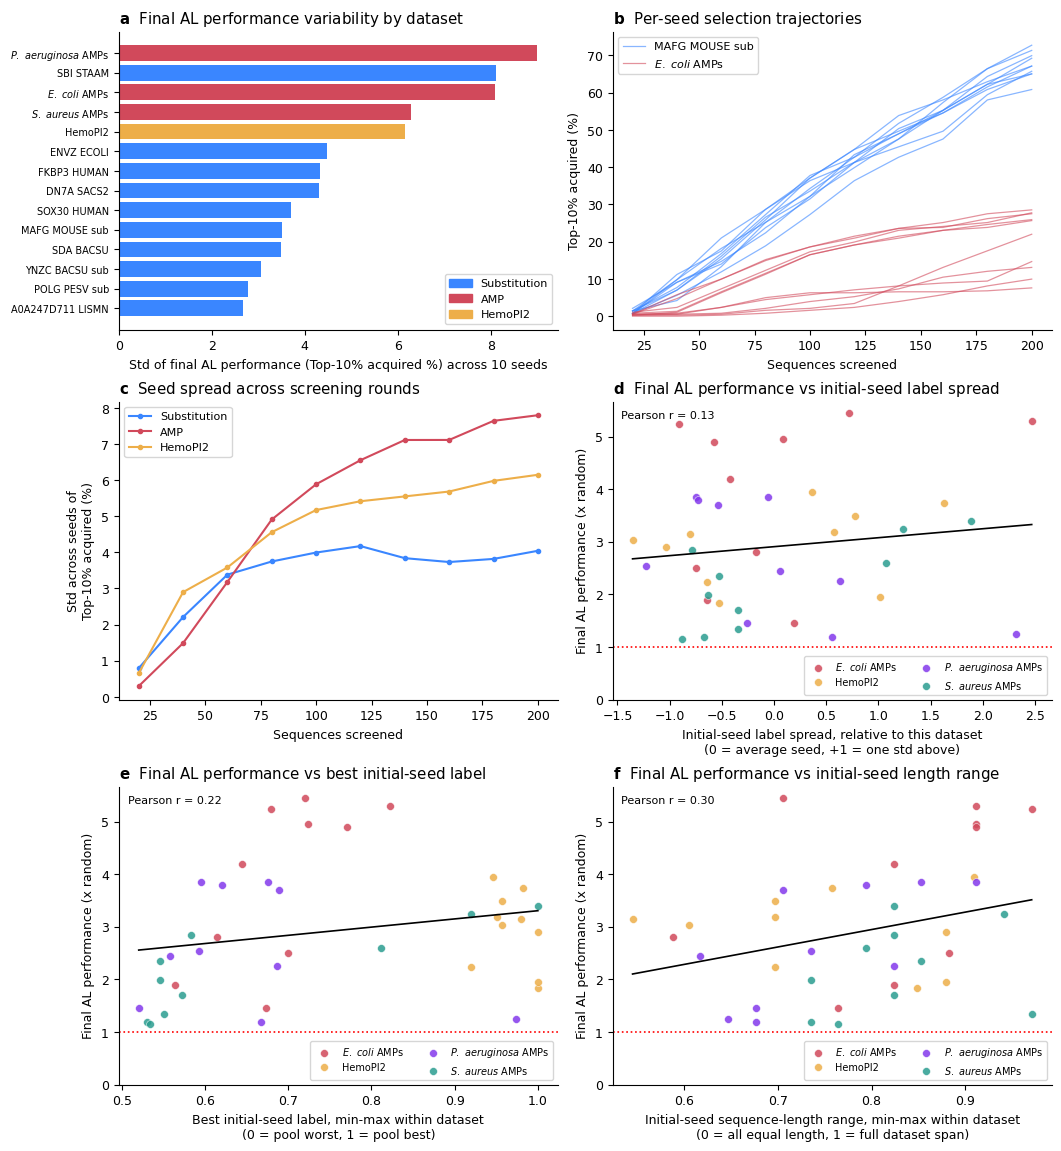

saved seed_variance_summary.png/.pdf to simulation_results/figures/seed_variance


In [5]:
# ================= FINAL FIGURE =================
n_seeds = int(end.groupby('Dataset')['Seed'].nunique().max())
fig, axd = plt.subplot_mosaic([['A','B'],['C','D'],['E','F']],
                              figsize=(10.5, 11.4), constrained_layout=True)

# (a) end-point std by dataset
sA = stats.sort_values('std')
axd['A'].barh([pretty_dataset(x) for x in sA['Dataset']], sA['std'], color=[colours[g] for g in sA['group']])
axd['A'].set_xlabel('Std of final AL performance (Top-10%% acquired %%) across %d seeds' % n_seeds)
axd['A'].set_title(r'$\mathbf{a}$  Final AL performance variability by dataset', loc='left')
hs=[plt.Rectangle((0,0),1,1,color=colours[g]) for g in ['Substitution','AMP','HemoPI2']]
axd['A'].legend(hs,['Substitution','AMP','HemoPI2'],fontsize=8,loc='lower right')
axd['A'].tick_params(axis='y', labelsize=7)

# (b) trajectory fans: one AMP vs one substitution
amp_ex = 'Ecoli_AMPs' if 'Ecoli_AMPs' in al['Dataset'].unique() else AMP_DATASETS[0]
_subs = [d for d in SUBSTITUTION_DATASETS if d in al['Dataset'].unique()]
sub_ex = 'MAFG_MOUSE_sub' if 'MAFG_MOUSE_sub' in al['Dataset'].unique() else (_subs[0] if _subs else amp_ex)
for d,col in [(sub_ex, colours['Substitution']), (amp_ex, colours['AMP'])]:
    sub=al[al['Dataset']==d]
    for i,(sd,g) in enumerate(sub.groupby('Seed')):
        g=g.sort_values('Num_samples')
        axd['B'].plot(g['Num_samples'], g['Value'], color=col, lw=0.9, alpha=0.6, label=pretty_dataset(d) if i==0 else None)
axd['B'].set_xlabel('Sequences screened'); axd['B'].set_ylabel('Top-10% acquired (%)')
axd['B'].set_title(r'$\mathbf{b}$  Per-seed selection trajectories', loc='left')
axd['B'].legend(fontsize=8, loc='upper left')

# (c) the seed-to-seed spread grows as screening proceeds
spread = al.groupby(['Dataset','Num_samples'])['Value'].std().reset_index(name='sd')
spread['group'] = spread['Dataset'].map(group_of)
for grp in ['Substitution','AMP','HemoPI2']:
    gg = spread[spread['group']==grp].groupby('Num_samples')['sd'].mean()
    if len(gg): axd['C'].plot(gg.index, gg.values, marker='o', ms=3, color=colours[grp], label=grp)
axd['C'].set_xlabel('Sequences screened')
axd['C'].set_ylabel('Std across seeds of\nTop-10% acquired (%)')
axd['C'].set_title(r'$\mathbf{c}$  Seed spread across screening rounds', loc='left')
axd['C'].legend(fontsize=8, loc='upper left')

# ---- shared end-point-vs-random setup ----
pool_size = {}
for d in feat['Dataset'].unique():
    ld = load_data(d)
    if ld is not None: pool_size[d] = len(ld)
pct_random = {d: endpoint_n / pool_size[d] * 100 for d in pool_size}   # expected % of top-10% by random

# (d) uses within-dataset z-scoring (unchanged from before)
def endpoint_vs_seed_feature_z(ax, feature, xlabel, title):
    # x = each seed's feature z-scored within its own dataset (0 = average seed, +1 = one std above);
    # y = end-point performance as a multiple of random screening.
    dd = feat[feat['Dataset'].isin(pct_random)].copy()
    dd['endpoint_xrandom'] = dd['endpoint'] / dd['Dataset'].map(pct_random)
    dd['x'] = dd.groupby('Dataset')[feature].transform(lambda s:(s-s.mean())/(s.std()+1e-9))
    for d,g in dd.groupby('Dataset'):
        ax.scatter(g['x'], g['endpoint_xrandom'], s=32,
                   color=dataset_colour(d), alpha=0.85, edgecolor='white', linewidth=0.4, label=pretty_dataset(d))
    rr,_ = pearsonr(dd['x'], dd['endpoint_xrandom'])
    b1,b0 = np.polyfit(dd['x'], dd['endpoint_xrandom'], 1)
    xs = np.linspace(dd['x'].min(), dd['x'].max(), 50)
    ax.plot(xs, b0+b1*xs, color='black', lw=1.2)
    ax.axhline(1.0, color='red', ls=':', lw=1.2)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(xlabel); ax.set_ylabel('Final AL performance (x random)')
    ax.set_title(title, loc='left')
    ax.text(0.02,0.97,'Pearson r = %.2f' % rr, transform=ax.transAxes, va='top', fontsize=8)
    ax.legend(fontsize=7, loc='lower right', ncol=2)

# (e)/(f) use MIN-MAX normalisation against each dataset's own POSSIBLE range
def endpoint_vs_seed_feature_minmax(ax, xvals_by_row, xlabel, title):
    # xvals_by_row: a pandas Series aligned to `feat`, already min-max normalised to [0, 1].
    # The x-axis is fit to the observed data (with a small margin) rather than forced to
    # the full 0-1 range, so there is no large band of empty space when the seeds only
    # occupy part of the possible range.
    dd = feat[feat['Dataset'].isin(pct_random)].copy()
    dd['endpoint_xrandom'] = dd['endpoint'] / dd['Dataset'].map(pct_random)
    dd['x'] = xvals_by_row.loc[dd.index]
    dd = dd.dropna(subset=['x', 'endpoint_xrandom'])
    for d,g in dd.groupby('Dataset'):
        ax.scatter(g['x'], g['endpoint_xrandom'], s=32,
                   color=dataset_colour(d), alpha=0.85, edgecolor='white', linewidth=0.4, label=pretty_dataset(d))
    rr,_ = pearsonr(dd['x'], dd['endpoint_xrandom'])
    b1,b0 = np.polyfit(dd['x'], dd['endpoint_xrandom'], 1)
    xs = np.linspace(dd['x'].min(), dd['x'].max(), 50)
    ax.plot(xs, b0+b1*xs, color='black', lw=1.2)
    ax.axhline(1.0, color='red', ls=':', lw=1.2)
    ax.set_ylim(bottom=0)
    xlo, xhi = dd['x'].min(), dd['x'].max()
    pad = 0.05 * (xhi - xlo) if xhi > xlo else 0.02
    ax.set_xlim(xlo - pad, xhi + pad)                 # fit to data, no wasted 0..1 band
    ax.set_xlabel(xlabel); ax.set_ylabel('Final AL performance (x random)')
    ax.set_title(title, loc='left')
    ax.text(0.02,0.97,'Pearson r = %.2f' % rr, transform=ax.transAxes, va='top', fontsize=8)
    ax.legend(fontsize=7, loc='lower right', ncol=2)

# min-max the best label against each dataset's full possible label range:
#   0 = worst-possible peptide in the pool, 1 = the global-best peptide
best_minmax = feat.apply(
    lambda r: (r['seed_max_target'] - ds_range[r['Dataset']]['lab_min'])
              / ((ds_range[r['Dataset']]['lab_max'] - ds_range[r['Dataset']]['lab_min']) or 1.0),
    axis=1)

# min-max the seed's length range against each dataset's largest possible 20-subset span:
#   0 = all 20 peptides the same length, 1 = spans the full length range of the dataset
lenrange_minmax = feat.apply(
    lambda r: r['seed_len_range'] / (ds_range[r['Dataset']]['len_span_max'] or 1.0),
    axis=1)

# (d) spread of the initial seed's labels (within-dataset z-scored, unchanged)
endpoint_vs_seed_feature_z(
    axd['D'], 'seed_std_target',
    'Initial-seed label spread, relative to this dataset\n(0 = average seed, +1 = one std above)',
    r'$\mathbf{d}$  Final AL performance vs initial-seed label spread')

# (e) best label present in the initial seed (min-max vs the dataset's possible label range)
endpoint_vs_seed_feature_minmax(
    axd['E'], best_minmax,
    'Best initial-seed label, min-max within dataset\n(0 = pool worst, 1 = pool best)',
    r'$\mathbf{e}$  Final AL performance vs best initial-seed label')

# (f) sequence-length range of the initial seed (min-max vs the dataset's possible length span)
endpoint_vs_seed_feature_minmax(
    axd['F'], lenrange_minmax,
    'Initial-seed sequence-length range, min-max within dataset\n(0 = all equal length, 1 = full dataset span)',
    r'$\mathbf{f}$  Final AL performance vs initial-seed length range')

fig.savefig(os.path.join(FIG_DIR,'seed_variance_summary.png'), dpi=250, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR,'seed_variance_summary.pdf'), bbox_inches='tight')
plt.show()
print('saved seed_variance_summary.png/.pdf to', FIG_DIR)
